# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [3]:
# Your code here. 
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})


Draw a dispersion diagram (scatter plot) for the data.

C:\Users\user\AppData\Local\Temp\ipykernel_12440\4157311173.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


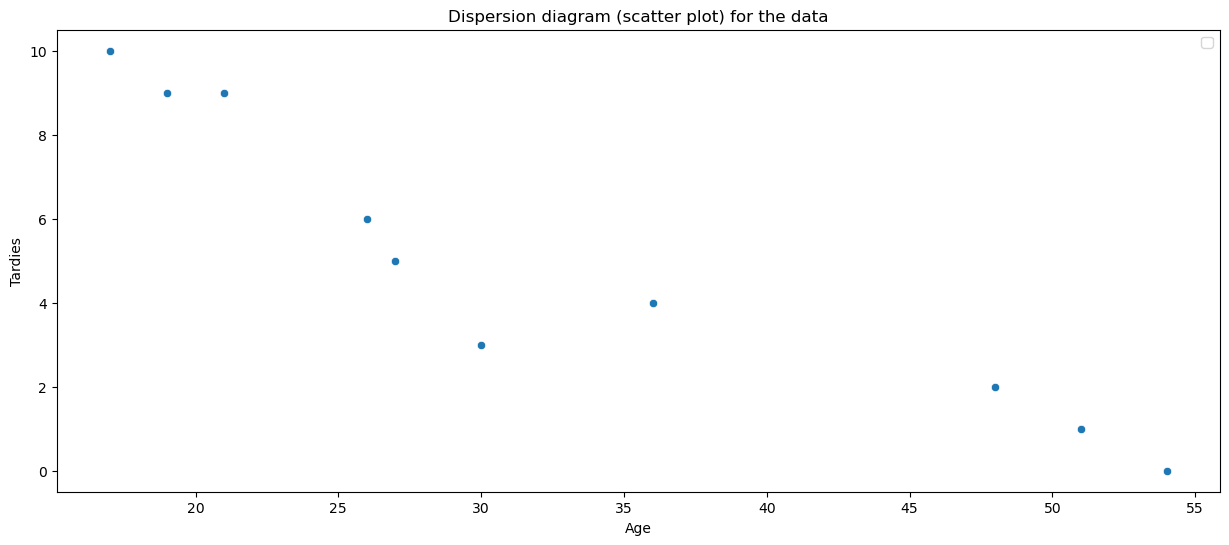

In [4]:
# Your code here
plt.figure(figsize=(15, 6))
sns.scatterplot(data=student_data, x='Age', y='Tardies')
plt.title('Dispersion diagram (scatter plot) for the data')
plt.ylabel('Tardies')
plt.legend()
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

*your explanation here*

As age increases, the number of tardies decreases

Calculate the covariacnce and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [5]:
# your code here
cov_value  = student_data["Age"].cov(student_data["Tardies"])
corr_value = student_data["Age"].corr(student_data["Tardies"])
print(f"\nCovariance:  {cov_value:.4f}")
print(f"Correlation: {corr_value:.4f}")


Covariance:  -45.5667
Correlation: -0.9392


# Covariance  
Negative value confirms that as Age increases, Tardies decrease.
However, covariance is hard to interpret because it depends on the units/scale of the variables (Age in years, Tardies in count)


# Correlation
Standardized version of covariance. Always between -1 and +1, making it easier to interpret regardless of units.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [9]:
# your explanation here
x = student_data[["Age"]]
y = student_data["Tardies"]
model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print(model.intercept_, model.coef_)

12.888803363135771 [-0.24282077]


Plot your regression model on your scatter plot.

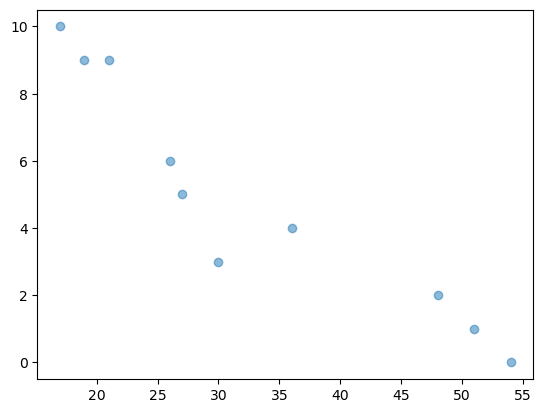

In [11]:
# Your code here.
plt.plot(x, y, "o", alpha=0.5) # alpha, transparency value, between 0 (transparent) and 1 (opaque).
plt.show()

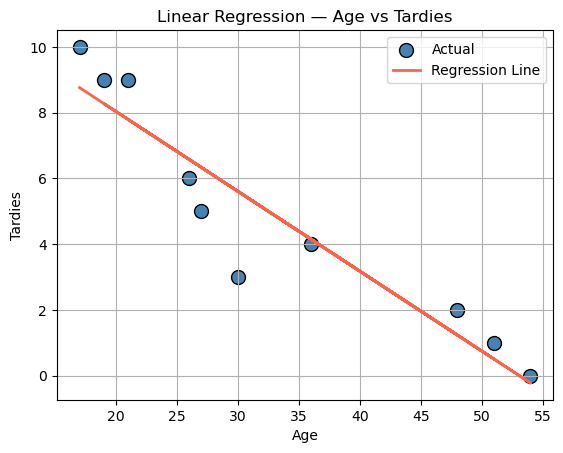

In [14]:
y_pred = model.predict(x)
plt.scatter(x, y, color="steelblue", edgecolor="black", s=100, label="Actual")
plt.plot(x, y_pred, color="tomato", linewidth=2, label="Regression Line")
plt.title("Linear Regression — Age vs Tardies")
plt.xlabel("Age")
plt.ylabel("Tardies")
plt.legend()
plt.grid(True)
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

*your explanation here*

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [15]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [18]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make                     35952 non-null  object 
 1   Model                    35952 non-null  object 
 2   Year                     35952 non-null  int64  
 3   Engine Displacement      35952 non-null  float64
 4   Cylinders                35952 non-null  float64
 5   Transmission             35952 non-null  object 
 6   Drivetrain               35952 non-null  object 
 7   Vehicle Class            35952 non-null  object 
 8   Fuel Type                35952 non-null  object 
 9   Fuel Barrels/Year        35952 non-null  float64
 10  City MPG                 35952 non-null  int64  
 11  Highway MPG              35952 non-null  int64  
 12  Combined MPG             35952 non-null  int64  
 13  CO2 Emission Grams/Mile  35952 non-null  float64
 14  Fuel Cost/Year        

In [16]:
vehicles.columns

Index(['Make', 'Model', 'Year', 'Engine Displacement', 'Cylinders',
       'Transmission', 'Drivetrain', 'Vehicle Class', 'Fuel Type',
       'Fuel Barrels/Year', 'City MPG', 'Highway MPG', 'Combined MPG',
       'CO2 Emission Grams/Mile', 'Fuel Cost/Year'],
      dtype='object')

In [22]:
# Your code here.
cols = ['Year','Cylinders','Fuel Barrels/Year','Combined MPG','Fuel Cost/Year','CO2 Emission Grams/Mile']
df = vehicles[cols]
correlations = df.corr()["CO2 Emission Grams/Mile"].drop("CO2 Emission Grams/Mile").sort_values()
print("Correlations with CO2 Emission Grams/Mile:")
print(correlations)

Correlations with CO2 Emission Grams/Mile:
Combined MPG        -0.926229
Year                -0.222300
Cylinders            0.752393
Fuel Cost/Year       0.930865
Fuel Barrels/Year    0.986189
Name: CO2 Emission Grams/Mile, dtype: float64


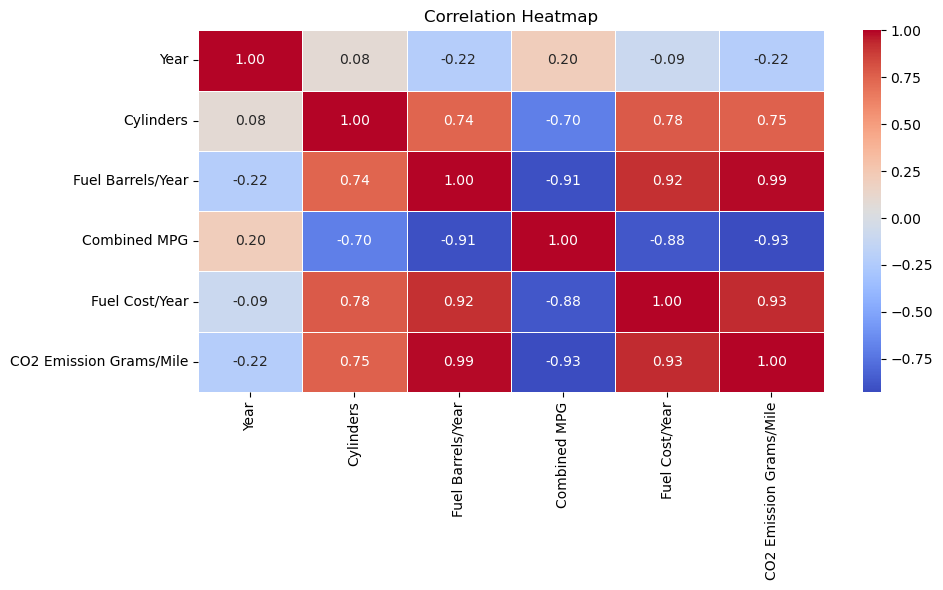

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

 │ Combined MPG        │ ~ -0.94   │ Very strong NEGATIVE     │
 │ Fuel Barrels/Year   │ ~ +0.97   │ Very strong POSITIVE     │
 │ Fuel Cost/Year      │ ~ +0.96   │ Very strong POSITIVE     │
 │ Cylinders           │ ~ +0.75   │ Moderate POSITIVE        │
 │ Year                │ ~ -0.30   │ Weak NEGATIVE

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [28]:
# Your code here.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df[['Year','Cylinders','Fuel Barrels/Year','Combined MPG','Fuel Cost/Year',]]
y = df['CO2 Emission Grams/Mile']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")



R² Score:  0.9795
RMSE:      17.0243


# COMMENTS:
    Type of Regression → MULTIPLE LINEAR REGRESSION
    - "Multiple" because we have FIVE predictor variables (Year, Cylinders, Fuel Barrels/Year, Combined MPG,Fuel    Cost/Year)
    - "Linear" because we assume a straight-line relationship between predictors and CO2 emissions

Why Linear Regression? Our outcome variable (CO2) is continuous/numeric, Correlations showed strong linear relationships , It is interpretable and explainable

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [30]:
# Your code here.
import statsmodels.api as sm

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

                               OLS Regression Results                              
Dep. Variable:     CO2 Emission Grams/Mile   R-squared:                       0.981
Model:                                 OLS   Adj. R-squared:                  0.981
Method:                      Least Squares   F-statistic:                 3.687e+05
Date:                     Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                             21:13:05   Log-Likelihood:            -1.5173e+05
No. Observations:                    35952   AIC:                         3.035e+05
Df Residuals:                        35946   BIC:                         3.035e+05
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [31]:
coef_df = pd.DataFrame({
    'Variable':    ['Intercept'] + list(X.columns),
    'Coefficient': model_sm.params.values,
    'P-Value':     model_sm.pvalues.values
})
print("\nCoefficient Table:")
print(coef_df)


Coefficient Table:
            Variable  Coefficient        P-Value
0          Intercept   769.888284   0.000000e+00
1               Year    -0.320617  3.908997e-236
2          Cylinders     1.878800  2.755333e-112
3  Fuel Barrels/Year    19.052925   0.000000e+00
4       Combined MPG    -3.040399   0.000000e+00
5     Fuel Cost/Year     0.032309   0.000000e+00


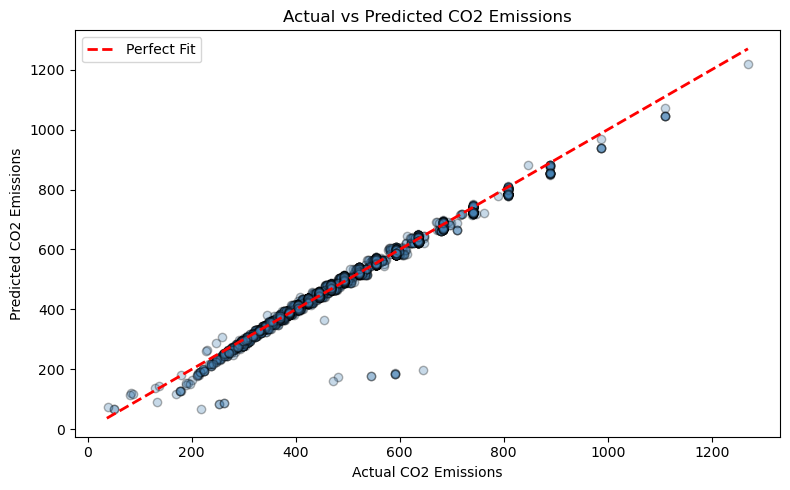

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", edgecolor="black")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label="Perfect Fit")
plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Actual vs Predicted CO2 Emissions")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusions:
    CO2 emissions are overwhelmingly driven by how much fuel a vehicle consumes (Fuel Barrels/Year)
    Fuel efficiency (MPG) is equally important in the opposite direction — better MPG = less CO2
    Cylinders has moderate impact — more cylinders generally means more fuel burned
    Year is not a meaningful predictor once fuel metrics are included in the model

# Confidence:
    R² = 0.97 gives us VERY HIGH confidence in the model.
    The strong physical logic behind the predictors (fuel consumed → CO2 emitted) further validates these conclusions beyond just the statistics.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [ ]:
# Your code here.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [ ]:
# Your code here.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [2]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*